# **Financial comments sentiment prediction**

## **Project Overview**
The primary objective of this project is to analyze the sentiment of financial comments and build a model that can classify sentences into positive, neutral, or negative sentiment categories.

## **Data Sources**
- **financial_data.csv**  
  - Contains financial sentences with assigned analysis - positive, neutral or negative.
  - The dataset was preprocessed to remove noise (stopwords, special characters etc.).

## **Project Workflow**
### **1. Exploratory Data Analysis (EDA)**
- Performed an in-depth analysis of comments and their sentiment.
- Used word clouds and frequency analysis to identify key patterns in the comments.
- Applied TF-IDF and word embeddings to better understand word importance.

### **2. Machine Learning for Sentiment Classification**
- Built multiple classification models to predict **sentiment**, including:
    - Logistic Regression,
    - Random Forest,
    - Support Vector Machine (SVM).
- Used GridSearchCV to optimize hyperparameters for better accuracy and performance.

### **3. Model Evaluation & Comparison**
- Evaluated models using:
    - Accuracy, Precision, Recall, F1-score
    - Confusion matrix visualization
- Identified the best-performing model based on classification metrics.

### **4. Conclusions**
- Summarized key findings from the analysis and predictions - more at the end of the project.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import string
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_curve
from textblob import TextBlob
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("financial_data.csv")
print(df.head())

                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


In [3]:
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


<Axes: xlabel='count', ylabel='Sentiment'>

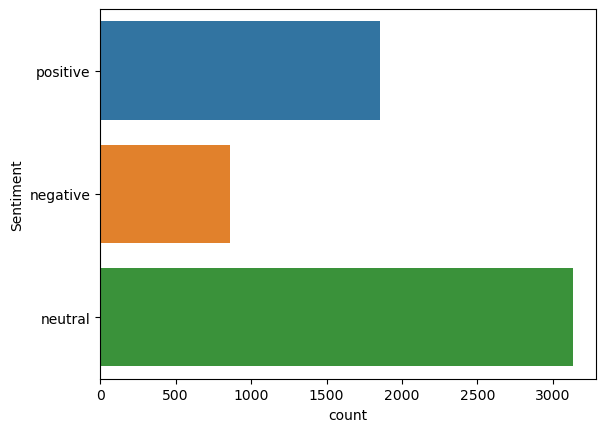

In [5]:
sns.countplot(y='Sentiment', data=df)

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

In [7]:
df['cleaned_text'] = df['Sentence'].astype(str).apply(clean_text)

In [8]:
df['Polarity'] = df['Sentence'].map(lambda text: TextBlob(text).sentiment.polarity)

In [9]:
df['Length'] = df['Sentence'].astype(str).apply(len)

In [10]:
df['NumberOfWords'] = df['Sentence'].apply(lambda x: len(str(x).split()))

In [11]:
df.head()

,Sentence,Sentiment,cleaned_text,Polarity,Length,NumberOfWords
0,The GeoSolutions technology will leverage Bene...,positive,the geosolutions technology will leverage bene...,0.209091,218,32
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi on lows down to bk a real possibility,0.022222,55,11
2,"For the last quarter of 2010 , Componenta 's n...",positive,for the last quarter of componenta s net sal...,0.000000,193,39
3,According to the Finnish-Russian Chamber of Co...,neutral,according to the finnishrussian chamber of com...,0.062500,128,20
4,The Swedish buyout firm has sold its remaining...,neutral,the swedish buyout firm has sold its remaining...,-0.100000,135,23


In [12]:
df.nsmallest(15, 'Polarity')

,Sentence,Sentiment,cleaned_text,Polarity,Length,NumberOfWords
1403,Windows 10 is awful why did it force an upgrad...,negative,windows is awful why did it force an upgrade ...,-1.0,102,19
198,The company has established a 3G base station ...,positive,the company has established a g base station a...,-0.8,218,39
2280,"Besides , as there is no depositor preference ...",neutral,besides as there is no depositor preference i...,-0.8,159,31
2422,Capital base and capital adequacy measurement ...,neutral,capital base and capital adequacy measurement ...,-0.8,85,14
4147,Mr Jortikka is president of the base metal div...,neutral,mr jortikka is president of the base metal div...,-0.8,124,23
4206,$CHRM Loooooongggggg base,positive,chrm loooooongggggg base,-0.8,25,3
4403,$MA http://stks.co/1CYN continues to consolida...,positive,ma httpstkscocyn continues to consolidate bas...,-0.8,60,8
4580,Airvana 's UMTS Home Base Station femto cell u...,positive,airvana s umts home base station femto cell us...,-0.8,164,23
4655,There has been some recovery of the base metal...,positive,there has been some recovery of the base metal...,-0.8,107,20
2522,"At this growth rate , paying off the national ...",neutral,at this growth rate paying off the national d...,-0.7,78,15


In [13]:
df.nlargest(15, 'Polarity')

,Sentence,Sentiment,cleaned_text,Polarity,Length,NumberOfWords
801,"While I cant understand what theyre saying , i...",neutral,while i cant understand what theyre saying it...,1.000000,104,20
1637,You are warmly welcome !,neutral,you are warmly welcome,1.000000,24,5
2113,$FB bot some @78.47 breakout from the consolid...,positive,fb bot some breakout from the consolidation z...,1.000000,59,10
2145,Welcome !,neutral,welcome,1.000000,9,2
2171,$FB Dax says bye bye 2013 - finished a great y...,positive,fb dax says bye bye finished a great yr w plus,1.000000,59,14
2340,$ETN UPGRADE today by MS to overweight. Excel...,positive,etn upgrade today by ms to overweight excelle...,1.000000,73,11
2819,`` In terms of profitability and earnings 2007...,positive,in terms of profitability and earnings was t...,1.000000,126,23
5048,$BBRY Sierra. Has a great cash balance and imp...,positive,bbry sierra has a great cash balance and impre...,0.933333,96,15
4149,The pilot project proved that RIFD technology ...,positive,the pilot project proved that rifd technology ...,0.900000,140,24
29,All are welcome .,neutral,all are welcome,0.800000,17,4


In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Sentiment'] = label_encoder.fit_transform(df['Sentiment'])

<Axes: >

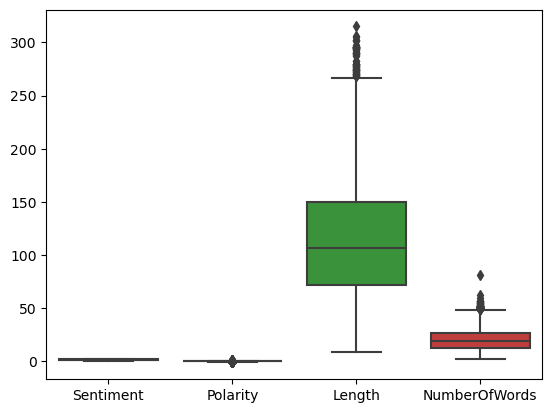

In [15]:
sns.boxplot(df)

count    5842.000000
mean        0.039192
std         0.182882
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.080000
max         1.000000
Name: Polarity, dtype: float64


Text(0.5, 1.0, 'Positive Sentiment')

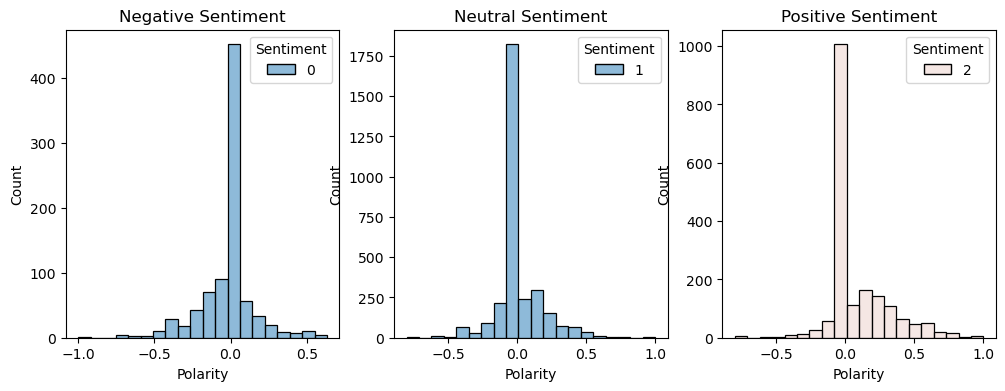

In [16]:
print(df['Polarity'].describe())
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(data=df[df['Sentiment']==0], x='Polarity', hue='Sentiment', bins=20, ax=ax[0]).set_title("Negative Sentiment")
sns.histplot(data=df[df['Sentiment']==1], x='Polarity', hue='Sentiment', bins=20, ax=ax[1]).set_title("Neutral Sentiment")
sns.histplot(data=df[df['Sentiment']==2], x='Polarity', hue='Sentiment', bins=20, ax=ax[2]).set_title("Positive Sentiment")

count    5842.000000
mean      117.022253
std        56.420425
min         9.000000
25%        72.000000
50%       107.000000
75%       150.000000
max       315.000000
Name: Length, dtype: float64


Text(0.5, 1.0, 'Positive Sentiment')

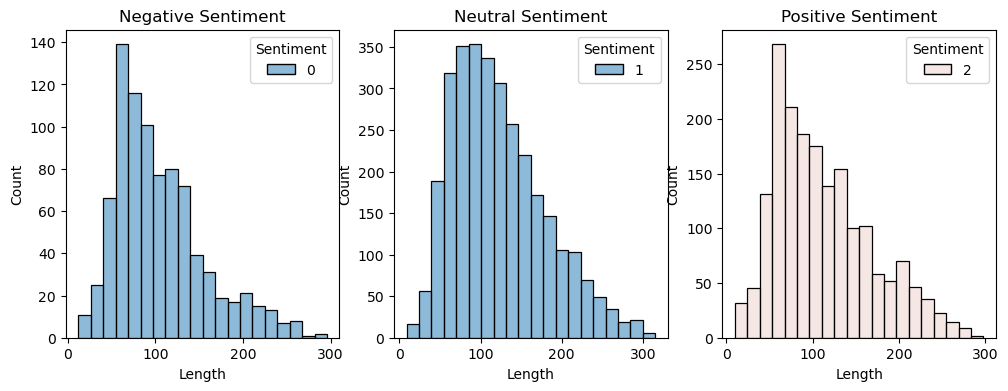

In [17]:
print(df['Length'].describe())
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(data=df[df['Sentiment']==0], x='Length', hue='Sentiment', bins=20, ax=ax[0]).set_title("Negative Sentiment")
sns.histplot(data=df[df['Sentiment']==1], x='Length', hue='Sentiment', bins=20, ax=ax[1]).set_title("Neutral Sentiment")
sns.histplot(data=df[df['Sentiment']==2], x='Length', hue='Sentiment', bins=20, ax=ax[2]).set_title("Positive Sentiment")

count    5842.000000
mean       21.004793
std        10.306465
min         2.000000
25%        13.000000
50%        19.000000
75%        27.000000
max        81.000000
Name: NumberOfWords, dtype: float64


Text(0.5, 1.0, 'Positive Sentiment')

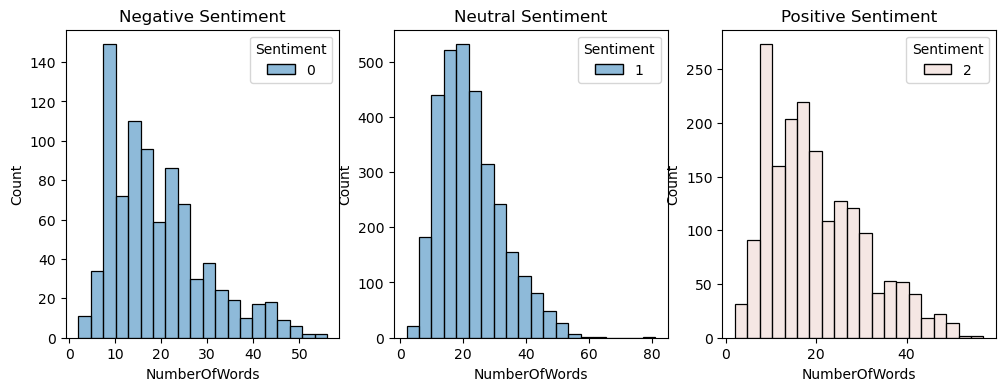

In [18]:
print(df['NumberOfWords'].describe())
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(data=df[df['Sentiment']==0], x='NumberOfWords', hue='Sentiment', bins=20, ax=ax[0]).set_title("Negative Sentiment")
sns.histplot(data=df[df['Sentiment']==1], x='NumberOfWords', hue='Sentiment', bins=20, ax=ax[1]).set_title("Neutral Sentiment")
sns.histplot(data=df[df['Sentiment']==2], x='NumberOfWords', hue='Sentiment', bins=20, ax=ax[2]).set_title("Positive Sentiment")

In [19]:
def countTopWords(data):
    vectorizer = CountVectorizer(stop_words='english')
    top_words = vectorizer.fit_transform(data)
    word_counts = pd.DataFrame(top_words.toarray(), columns=vectorizer.get_feature_names_out())
    word_counts = word_counts.sum().sort_values(ascending=False)
    print(word_counts.head(10))

In [20]:
countTopWords(df['Sentence'])

eur        1286
company     810
mn          729
profit      569
sales       562
finnish     539
said        516
net         500
million     493
year        479
dtype: int64


In [21]:
countTopWords(df[df['Sentiment']==0]['Sentence'])

eur          311
mn           220
profit       154
sales        105
net          100
year         100
finnish       91
operating     89
quarter       87
2009          81
dtype: int64


In [22]:
countTopWords(df[df['Sentiment']==1]['Sentence'])

eur        538
company    527
mn         270
finnish    267
said       258
million    250
sales      241
finland    236
profit     212
net        203
dtype: int64


In [23]:
countTopWords(df[df['Sentiment']==2]['Sentence'])

eur        437
mn         239
year       218
sales      216
company    203
profit     203
net        197
said       194
finnish    181
million    164
dtype: int64


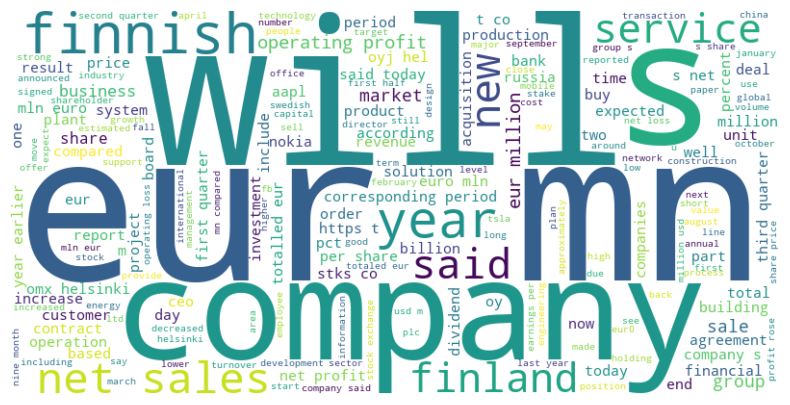

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Sentence']).lower()
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['Sentiment'], test_size=0.2, random_state=42)

In [26]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [27]:
def predict(model):

    if model=="LogisticRegression":
        model = LogisticRegression()
        param = {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        }
        
    elif model=="RandomForest":
        model = RandomForestClassifier()
        param = {
            'n_estimators': [100, 300, 500],  
            'max_depth': [10, 20, None],  
            'max_features': ['sqrt', 'log2'],  
            'min_samples_split': [2, 5, 10]
        }
        
    elif model=="SVM":
        model = SVC()
        param = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 0.01, 0.1, 1]
        }

    grid = GridSearchCV(model, param, cv=5, scoring='f1_weighted', n_jobs=-1)

    grid.fit(X_train_tfidf, y_train)

    print("The best parameters: ", grid.best_params_)
    print("The best accuraccy: ", grid.best_score_)

In [28]:
def confusionMatrix(y_test, y_pred):
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# Logistic regression

In [29]:
predict("LogisticRegression")

The best parameters:  {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
The best accuraccy:  0.6773435266117396


In [30]:
model = LogisticRegression(C=10, penalty='l2', solver='liblinear')
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7091531223267751
              precision    recall  f1-score   support

           0       0.36      0.25      0.30       175
           1       0.72      0.82      0.77       622
           2       0.81      0.73      0.77       372

    accuracy                           0.71      1169
   macro avg       0.63      0.60      0.61      1169
weighted avg       0.70      0.71      0.70      1169



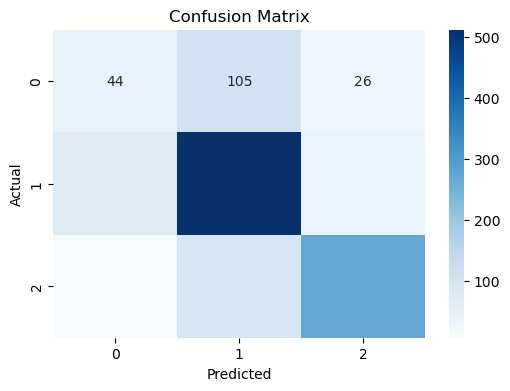

In [31]:
confusionMatrix(y_test, y_pred)

In [42]:
example_text = ["The stock market is crashing again!"]
example_tfidf = tfidf.transform(example_text)
prediction = model.predict(example_tfidf)
print("Predicted sentiment:", prediction)

Predicted sentiment: [1]


# Random forest

In [33]:
predict("RandomForest")

The best parameters:  {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 300}
The best accuraccy:  0.6145138542285389


In [34]:
model_forest = RandomForestClassifier(max_depth=None, max_features='sqrt', min_samples_split=5, n_estimators=100, class_weight='balanced')
model_forest.fit(X_train_tfidf, y_train)

y_pred = model_forest.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6432848588537211
              precision    recall  f1-score   support

           0       0.26      0.17      0.21       175
           1       0.66      0.80      0.72       622
           2       0.75      0.60      0.66       372

    accuracy                           0.64      1169
   macro avg       0.56      0.52      0.53      1169
weighted avg       0.63      0.64      0.63      1169



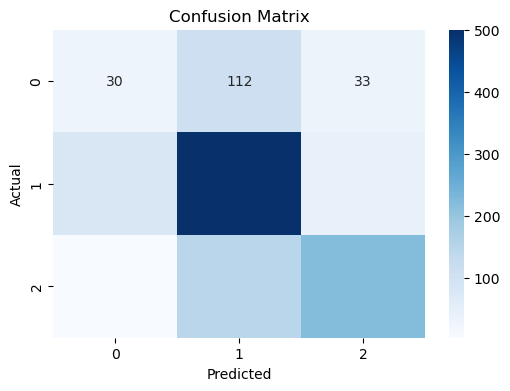

In [35]:
confusionMatrix(y_test, y_pred)

In [41]:
example_text = ["The stock market is crashing again!"]
example_tfidf = tfidf.transform(example_text)
prediction = model_forest.predict(example_tfidf)
print("Predicted sentiment:", prediction)

Predicted sentiment: [1]


# SVM

In [37]:
predict("SVM")

The best parameters:  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
The best accuraccy:  0.6855464533358246


In [38]:
modelsvm = SVC(C=1, gamma='scale', kernel='linear')
modelsvm.fit(X_train_tfidf, y_train)

y_pred = modelsvm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7331052181351583
              precision    recall  f1-score   support

           0       0.53      0.19      0.28       175
           1       0.72      0.91      0.80       622
           2       0.80      0.69      0.74       372

    accuracy                           0.73      1169
   macro avg       0.69      0.60      0.61      1169
weighted avg       0.72      0.73      0.71      1169



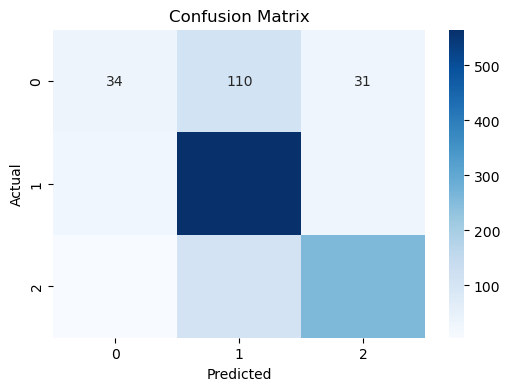

In [39]:
confusionMatrix(y_test, y_pred)

In [40]:
example_text = ["The stock market is crashing again!"]
example_tfidf = tfidf.transform(example_text)
prediction = modelsvm.predict(example_tfidf)
print("Predicted sentiment:", prediction)

Predicted sentiment: [1]


## **Conclusions**

1. **Financial sentiment analysis**  
   - The dataset is unbalanced - there are more data with neutral sentiment compared to negative sentiment.
   - In all classes, the most frequently occuring words are similar.
   - The distribution of sentence length and the number of words in each class is similar.

2. **Key Findings from Predictive Modeling**
    - GridSearchCV is useful for finding the best hyperparameters, but it is computationally expensive. Because the dataset is unbalanced and has three classes, the best scoring metric in this case is 'f1_weighted'.
   - *Logistic regression*
     - Accuracy is 70.91%.
     - The neutral class (1) is the most frequently predicted class.
     - The recall of 25% for negative class (0) means that most negative instances are misclassified.
     - Most of the data from class positive (2) is properly predicted.
   - *Random forest*
     -  Accuracy is 64.58%.
     -  The negative class (0) has a high number of false positive (precision=25%).
     -  The neutral class (1) has a F1-score of 0.72 - it means about a relativelygood classification quality.
     -  The positive class (2) is better detected than the negative one.
   - *SVM*
     -  This model achieves the highest accuracy among the tested models - 73.31%.
     -  The negative class (0) has a precision of 0.53 - it means that there are a lot of false positives and model has a difficulty in detecting negative comments.
     -  The neutral class (1) is well classified with high Precision (0.72), Recall (0.91) and F1-score (0.8) - model is good in predicting neutral sentences.
     -  The positive class (2) is generally well predicted, but some positive instances are still misclassified (recall = 0.69).
     
3. **Conclusions**
   - The predictive models perform well in detecting neutral class (1).
   - If the negative class (0) is a priority, the model needs to be improved.
   - The dataset are unbalanced and it makes it more difficult to build an effective classification model.
   - SVM model (support vector machine) is the best for predict financial sentiment, achieving the best accuracy and the best F1-score, Precision and Recall.

4. **Future Work and Improvements**  
   - Integrating additional features to enhance classification performance. 
   - Exploring deep learning models (e.g. LSTM) for sentiment analysis.  
   - Addressing data imbalanced using SMOTE (oversamling), undersampling and adjusting class weights.

